In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = 1500

data = {
    "PM2.5": np.random.randint(10, 250, rows),
    "PM10": np.random.randint(20, 350, rows),
    "NO2": np.random.randint(5, 120, rows),
    "SO2": np.random.randint(2, 80, rows),
    "CO": np.round(np.random.uniform(0.2, 8.0, rows), 2),
    "O3": np.random.randint(10, 180, rows),
    "Temperature": np.random.randint(10, 45, rows),
    "Humidity": np.random.randint(20, 100, rows),
    "WindSpeed": np.round(np.random.uniform(0.5, 15.0, rows), 2),
    "AQI": np.random.randint(30, 500, rows)
}

df = pd.DataFrame(data)

df.to_csv("air_pollution_1500.csv", index=False)

print("Dataset created successfully!")


Dataset created successfully!


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop("AQI", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.12382391 0.12109616]


In [4]:
df.head()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,WindSpeed,AQI
0,112,316,23,66,7.49,62,11,91,11.95,492
1,189,233,46,44,5.57,47,25,85,9.70,317
2,102,286,39,40,6.62,62,10,25,8.22,111
3,24,276,50,60,4.54,152,20,50,6.19,363
4,116,321,30,45,6.28,163,44,29,4.73,279


In [5]:
df.tail()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,WindSpeed,AQI
1495,146,273,98,18,0.79,104,11,94,13.52,63
1496,60,137,100,17,1.08,64,23,43,4.02,253
1497,38,217,104,17,0.58,33,13,54,5.62,208
1498,215,70,115,47,2.21,161,22,89,14.28,275
1499,49,264,98,40,1.26,35,44,59,8.89,289


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PM2.5        1500 non-null   int32  
 1   PM10         1500 non-null   int32  
 2   NO2          1500 non-null   int32  
 3   SO2          1500 non-null   int32  
 4   CO           1500 non-null   float64
 5   O3           1500 non-null   int32  
 6   Temperature  1500 non-null   int32  
 7   Humidity     1500 non-null   int32  
 8   WindSpeed    1500 non-null   float64
 9   AQI          1500 non-null   int32  
dtypes: float64(2), int32(8)
memory usage: 70.4 KB


In [7]:
df.describe()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,WindSpeed,AQI
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,129.592667,184.726667,61.018667,41.244667,4.042727,94.758667,26.970000,59.530000,7.698673,263.539333
std,68.959338,95.914773,32.676977,22.302116,2.232786,48.565044,10.072772,23.290228,4.154602,133.690268
min,10.000000,20.000000,5.000000,2.000000,0.200000,10.000000,10.000000,20.000000,0.500000,30.000000
25%,69.750000,103.000000,32.750000,22.000000,2.130000,52.000000,18.000000,38.000000,4.257500,151.000000
50%,130.000000,181.000000,59.500000,41.000000,3.985000,96.000000,27.000000,60.000000,7.625000,268.000000
75%,189.000000,270.000000,90.000000,61.000000,5.932500,137.000000,36.000000,80.000000,11.152500,373.000000
max,249.000000,349.000000,119.000000,79.000000,7.990000,179.000000,44.000000,99.000000,14.990000,499.000000


In [8]:
df.shape

(1500, 10)

In [9]:
df.isnull()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,WindSpeed,AQI
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1495,False,False,False,False,False,False,False,False,False,False
1496,False,False,False,False,False,False,False,False,False,False
1497,False,False,False,False,False,False,False,False,False,False
1498,False,False,False,False,False,False,False,False,False,False


In [10]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [11]:
print (df.columns)

Index(['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity',
       'WindSpeed', 'AQI'],
      dtype='object')


In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [14]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

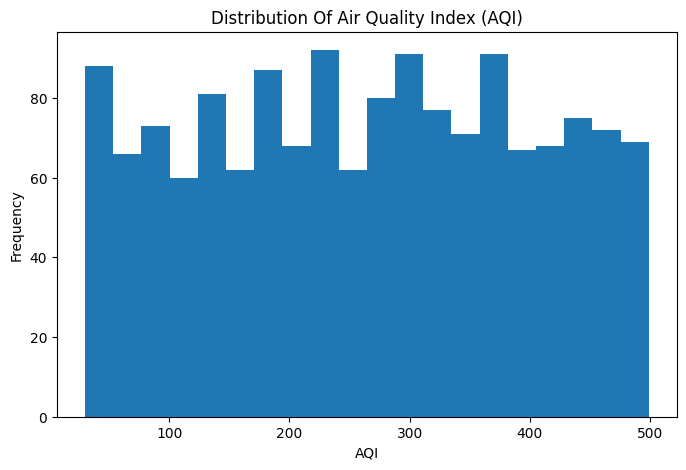

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["AQI"],bins=20)
plt.title("Distribution Of Air Quality Index (AQI)")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

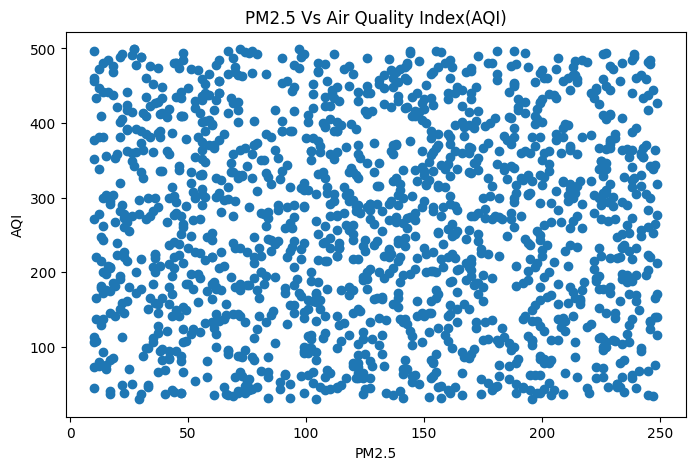

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df["PM2.5"], df["AQI"])
plt.title("PM2.5 Vs Air Quality Index(AQI)")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.show()

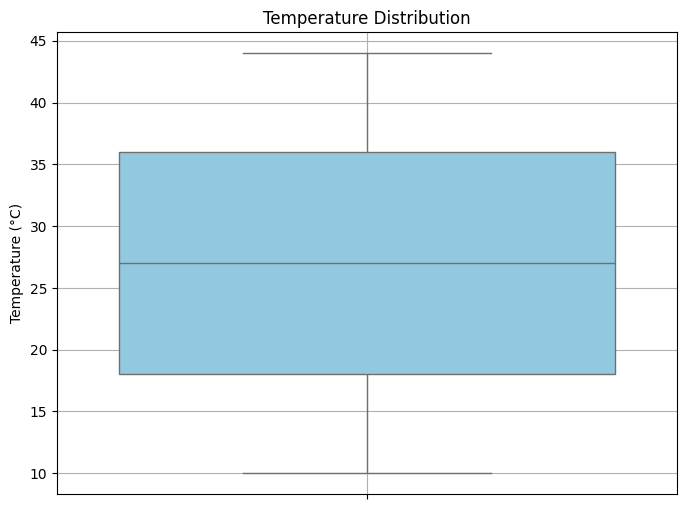

In [17]:
plt.figure(figsize=(8,6))

sns.boxplot(
    y=df["Temperature"],
    color="skyblue"
)

plt.title("Temperature Distribution")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.show()

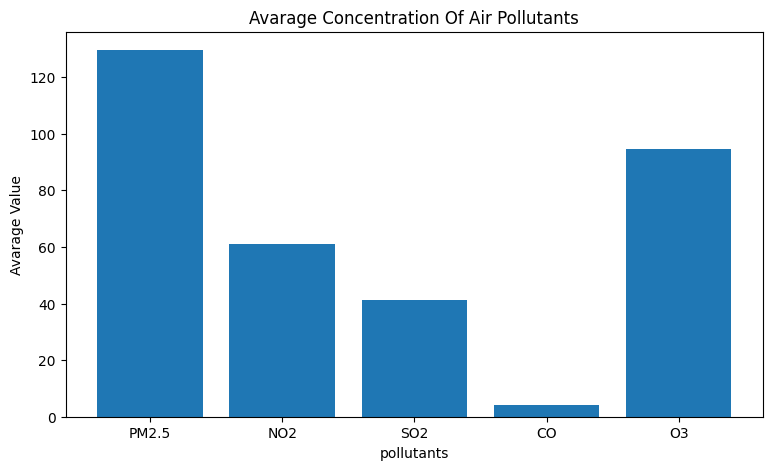

In [18]:
pollutants = ["PM2.5","NO2","SO2","CO","O3"]
plt.figure(figsize=(9,5))
plt.bar(pollutants,df[pollutants].mean())
plt.title("Avarage Concentration Of Air Pollutants")
plt.xlabel("pollutants")
plt.ylabel("Avarage Value")
plt.show()

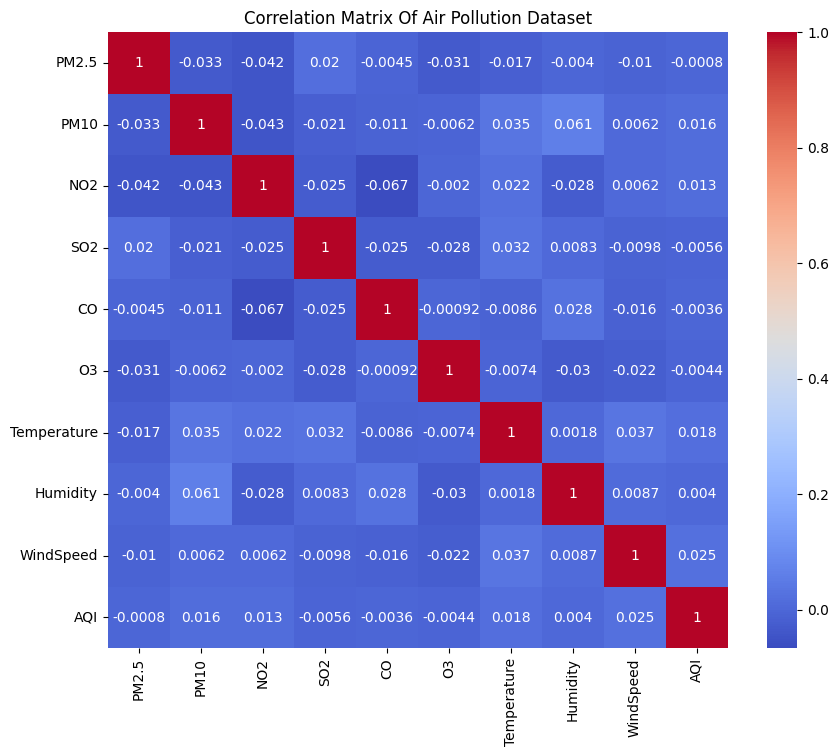

In [19]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True,cmap="coolwarm")
plt.title("Correlation Matrix Of Air Pollution Dataset")
plt.show()

In [20]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2"],
    index=X.columns
)

print(loadings)

                  PC1       PC2
PM2.5       -0.122831 -0.373369
PM10        -0.422478  0.422202
NO2          0.573051  0.282057
SO2         -0.074645  0.027983
CO          -0.399208 -0.305471
O3           0.206440 -0.130128
Temperature -0.013913  0.524922
Humidity    -0.519881  0.218139
WindSpeed   -0.003427  0.410642


In [26]:
def aqi_category(aqi):
    if aqi <= 100:
        return 0
    elif aqi <= 200:
        return 1
    elif aqi <= 300:
        return 2
    else:
        return 3

df["AQI_Category"] = df["AQI"].apply(aqi_category)

In [27]:
X = df.drop(["AQI","AQI_Category"], axis=1)

y = df["AQI_Category"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.4266666666666667


In [31]:
import joblib
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca,"pca.pkl")
joblib.dump(model, "model.pkl")
print("Files Saved Successfully!")

Files Saved Successfully!
